# Healthcare vs. Technology: what does negative correlation mean?

**Decision:** distinguish diversification, downside protection, and a relative-value trade.
Negative correlation describes joint risk; it does not forecast which sector will outperform.

**Data:** Yahoo Finance adjusted closes for XLV (healthcare), XLK (technology), and SPY (market).
The added SPX chart and event study use Yahoo `^GSPC` **Close**, a price index excluding dividends.
These are investable ETF proxies, not the exact S&P sector total-return indices.
Use all available common history for estimation; show the latest three years in charts.
The saved run ends **September 10, 2026**, matching the earlier dashboard; it is not a live update.
This short version uses SPDR only. The earlier detailed notebook retains the longer Fidelity comparison.

**Company workflow:** reproduce `df` at the handoff below, then copy Section 2 onward.
Sections 11-13 additionally need `spx`, a Series of SPX closing levels aligned to `df`.
Only pandas, numpy, matplotlib, and Jupyter are needed after the handoff. No project modules are imported.
Yahoo additionally needs yfinance. Bloomberg is an unexecuted, commented alternative in the same source cell.

## 1. Data source and cleaning

`END` is exclusive. Local Yahoo CSVs preserve the original snapshot; without them, download maximum history.
To refresh, set `USE_CACHE = False` and update `END`.
Adjusted closes approximate returns with dividends and splits; unadjusted `PX_LAST` is not equivalent.
The Bloomberg example uses the **legacy xbbg 0.7.x wide DataFrame BDH interface**;
check your installed wrapper and Bloomberg permissions before enabling it. BDH is sufficient for daily prices.
Cross-vendor return differences can remain even with matching adjustments.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

END = '2026-09-11'
USE_CACHE = True
symbols = {'XLV': 'HC', 'XLK': 'TECH', 'SPY': 'MKT', '^GSPC': 'SPX'}
series = {}
for ticker, name in symbols.items():
    path = Path('data/yahoo') / f'{ticker.replace("^", "INDEX_")}.csv'
    if USE_CACHE and path.exists():
        raw = pd.read_csv(path, index_col=0, parse_dates=True)
        source = 'Yahoo CSV cache'
    else:
        import yfinance as yf
        raw = yf.Ticker(ticker).history(period='max', auto_adjust=False, repair=False)
        source = 'Yahoo download'
    field = 'Close' if name == 'SPX' else 'Adj Close'
    series[name] = raw[field].rename(name)
    series[name].index = pd.to_datetime(series[name].index).tz_localize(None).normalize()
    print(ticker, source, '| field:', field)
prices = pd.concat(series, axis=1)

# Bloomberg: comment out Yahoo's series/loop/concat block, then uncomment below.
# from xbbg import blp
# securities = {'XLV US Equity': 'HC', 'XLK US Equity': 'TECH', 'SPY US Equity': 'MKT'}
# bb = blp.bdh(list(securities), 'PX_LAST', start_date='19980101',
#              end_date=(pd.Timestamp(END) - pd.Timedelta(days=1)).strftime('%Y%m%d'),
#              Per='D', CshAdjNormal=True, CshAdjAbnormal=True, CapChg=True)
# prices = bb.droplevel(1, axis=1).rename(columns=securities)
# bb_spx = blp.bdh('SPX Index', 'PX_LAST', start_date='19980101',
#                  end_date=(pd.Timestamp(END) - pd.Timedelta(days=1)).strftime('%Y%m%d'), Per='D')
# prices['SPX'] = bb_spx.iloc[:, 0]
# print('Bloomberg BDH | field: PX_LAST | cash and split adjustments enabled')

XLV Yahoo CSV cache | field: Adj Close
XLK Yahoo CSV cache | field: Adj Close
SPY Yahoo CSV cache | field: Adj Close
^GSPC Yahoo CSV cache | field: Close


In [2]:
prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
spx = prices['SPX'].rename('SPX')
prices = prices.sort_index().loc[lambda x: x.index < pd.Timestamp(END), ['HC', 'TECH', 'MKT']]
assert prices.index.is_unique, 'Duplicate dates: investigate before computing returns.'
observed = prices.stack().to_numpy()
assert len(observed) and np.isfinite(observed).all() and (observed > 0).all()
returns = prices.pct_change(fill_method=None)  # Compute BEFORE trimming; never fill missing prices.
complete = returns.dropna()
assert not complete.empty, 'No common daily returns.'
df = returns.loc[complete.index[0]:complete.index[-1]].astype('float64').copy()
df.index.name = 'Date'
assert df.notna().all().all(), 'Internal data gaps: repair the source; do not drop or fill days.'
df.to_csv('healthcare_technology_input.csv', float_format='%.17g')
spx = spx.reindex(df.index).astype('float64')
assert np.isfinite(spx.to_numpy()).all() and (spx > 0).all(), 'SPX must cover every df date.'
spx.to_csv('spx_index_input.csv', float_format='%.17g')

## DATA CLEANING COMPLETE - analysis starts from `df`

**Required input:** one row per common trading day; sorted, unique, timezone-naive `Date` index;
three `float64` columns in order **`HC`, `TECH`, `MKT`**; finite daily **simple adjusted returns**;
no missing values. **`0.01` means +1%, not +0.01%.** These are returns, not prices or cumulative returns.

`HC = XLV`, `TECH = XLK`, `MKT = SPY`. Example: `100 -> 101` gives `101 / 100 - 1 = 0.01`.
Preserve trading dates and the full common history: shortening the input changes historical thresholds.
Check the printed first/last dates, row count, and sample values against your company result.
The CSV is an optional exact handoff; Bloomberg need only produce the same schema, not identical vendor values.

After recreating `df`, **start Section 2 without running Section 1**.
For the added Sections 11-13, also prepare **`spx`**: a positive `float64` Series of **index levels**,
named `SPX`, with exactly the same index as `df`. Keep `df`'s three-column contract unchanged.

In [3]:
print('INPUT CONTRACT: daily adjusted returns in decimal units; 0.01 = 1%')
print(f'Shape: {df.shape} | Dates: {df.index.min().date()} to {df.index.max().date()}')
df.info()
print('\nFirst 3 and last 3 rows (10 decimal places):')
print(pd.concat([df.head(3), df.tail(3)]).to_string(float_format=lambda x: f'{x:.10f}'))
print('\nMissing values:', df.isna().sum().to_dict())
# Optional company input: df = pd.read_csv('healthcare_technology_input.csv', index_col='Date', parse_dates=True)
print('\nADDITIONAL INPUT: spx | SPX price index levels, not returns')
print(f'Shape: {spx.shape} | dtype: {spx.dtype} | matches df dates: {spx.index.equals(df.index)}')
print(pd.concat([spx.head(3), spx.tail(3)]).to_string())
# Optional: spx = pd.read_csv('spx_index_input.csv', index_col='Date', parse_dates=True)['SPX']

INPUT CONTRACT: daily adjusted returns in decimal units; 0.01 = 1%
Shape: (6970, 3) | Dates: 1998-12-23 to 2026-09-10
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6970 entries, 1998-12-23 to 2026-09-10
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HC      6970 non-null   float64
 1   TECH    6970 non-null   float64
 2   MKT     6970 non-null   float64
dtypes: float64(3)
memory usage: 217.8 KB

First 3 and last 3 rows (10 decimal places):
                      HC          TECH           MKT
Date                                                
1998-12-23  0.0224718575  0.0238913879  0.0209730995
1998-12-24  0.0061052215 -0.0038092618 -0.0043112618
1998-12-28 -0.0145628855  0.0028674979 -0.0025472414
2026-09-08 -0.0251968046  0.0031503436 -0.0054921259
2026-09-09 -0.0032908696  0.0000000000 -0.0046477590
2026-09-10 -0.0055228608 -0.0141054664 -0.0059942382

Missing values: {'HC': 0, 'TECH': 0, 'MKT': 0}

ADDITIONAL I

## 2. Three return definitions

| View | Daily calculation | Question answered |
|---|---|---|
| Absolute | $r_H$, $r_T$ | Do the holdings move together in dollar-return terms? |
| Relative | $a_H=r_H-r_M$, $a_T=r_T-r_M$ | Do they outperform the same benchmark together? |
| Market residual | $e_i=r_i-\hat\alpha_{i,t-1}-\hat\beta_{i,t-1}r_M$ | Is comovement left after allowing different market exposures? |

Example: market **-2%**, healthcare **-1%**, technology **-3%**. Relative returns are **+1%** and **-1%**,
although both holdings lose money. Relative is an arithmetic benchmark difference, not division by the market return.
The return on a relative wealth ratio is instead $(1+r_i)/(1+r_M)-1$; that is a different statistic.

Residual betas use the **previous 126 trading days**, with an intercept. This is a descriptive single-market-factor model,
not a causal explanation or a risk-free-rate-adjusted CAPM. Residuals can still share other factors.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

assert isinstance(df.index, pd.DatetimeIndex) and df.index.tz is None
assert df.index.is_unique and df.index.is_monotonic_increasing and not df.index.hasnans
assert list(df.columns) == ['HC', 'TECH', 'MKT'] and len(df) >= 504
assert all(dtype == np.dtype('float64') for dtype in df.dtypes)
assert np.isfinite(df.to_numpy()).all() and (df > -1).all().all()
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.2})
pd.set_option('display.max_columns', 12)
start = df.index[-1] - pd.DateOffset(years=3)
recent = df.loc[start:]
sectors = df[['HC', 'TECH']]
relative = sectors.sub(df.MKT, axis=0)
beta = sectors.rolling(126).cov(df.MKT).div(df.MKT.rolling(126).var(), axis=0).shift(1)
alpha = sectors.rolling(126).mean().shift(1) - beta.mul(df.MKT.rolling(126).mean().shift(1), axis=0)
residual = sectors - alpha - beta.mul(df.MKT, axis=0)
views = {'Absolute': sectors, 'Relative': relative, 'Market residual': residual}
print(f'Analysis as of {df.index[-1].date()} | chart sample: {len(recent)} daily returns')

Analysis as of 2026-09-10 | chart sample: 753 daily returns


## 3. Has the relationship changed?

Each point is the Pearson correlation of **21, 63, or 126 pairs of daily returns**, not two cumulative returns.
Twenty-one returns normally need 22 consecutive common prices. Short windows react faster and are noisier.
The table separates an unusual absolute correlation from a relative correlation that may usually be negative.
Historical negative shares describe past rolling windows; overlapping windows are not independent trials.

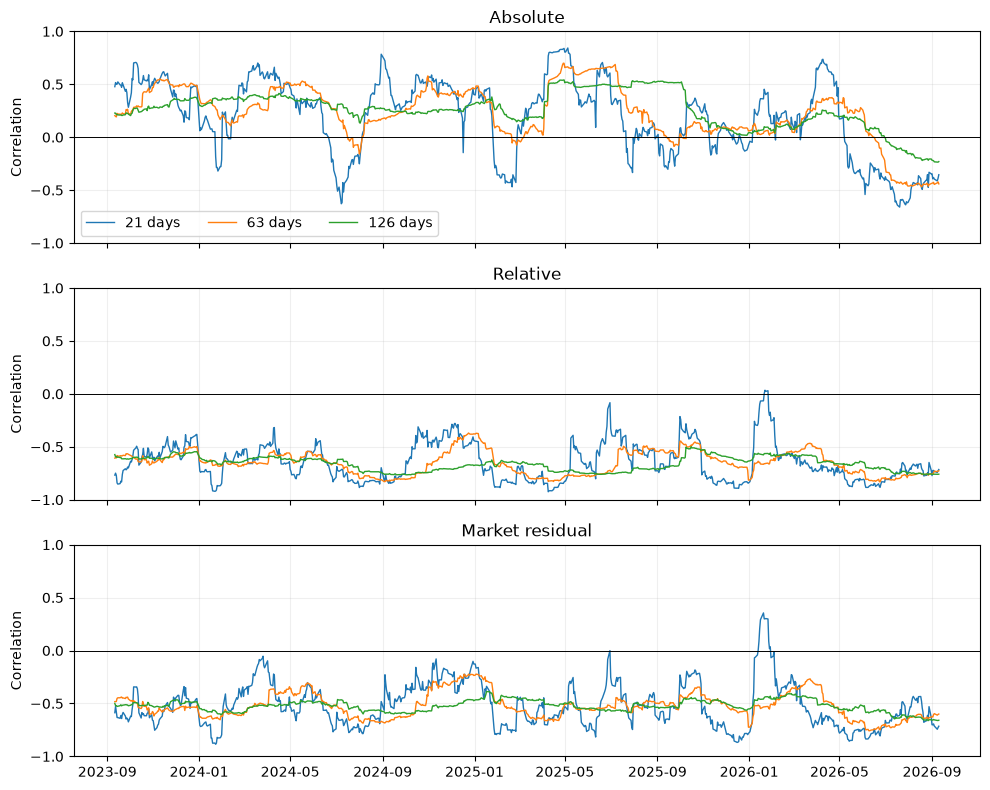

,View,Days,Latest rho,Historical negative share,Windows
0,Absolute,21,-0.355,0.042,6950
1,Absolute,63,-0.441,0.015,6908
2,Absolute,126,-0.231,0.007,6845
3,Relative,21,-0.715,0.752,6950
4,Relative,63,-0.727,0.815,6908
5,Relative,126,-0.759,0.845,6845
6,Market residual,21,-0.715,0.726,6824
7,Market residual,63,-0.600,0.799,6782
8,Market residual,126,-0.659,0.827,6719


In [5]:
rows = []
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (name, data) in zip(axes, views.items()):
    for window in [21, 63, 126]:
        rho = data.HC.rolling(window).corr(data.TECH).dropna()
        ax.plot(rho.loc[start:], label=f'{window} days', linewidth=1)
        rows.append([name, window, rho.iloc[-1], (rho < 0).mean(), len(rho)])
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set(title=name, ylim=(-1, 1), ylabel='Correlation')
axes[0].legend(ncol=3)
plt.tight_layout()
plt.show()
corr_table = pd.DataFrame(rows, columns=['View', 'Days', 'Latest rho', 'Historical negative share', 'Windows'])
display(corr_table.round(3))

## 4. Read the scatter plot one day at a time

**X:** healthcare daily relative return; **Y:** technology daily relative return, both in percent.
Dashed lines are **sample means**, not zero-return lines. Each dot is a date.
Green dots contribute negative covariance: one sector is above its own mean and the other is below its own mean.
Thus correlation does not count opposite absolute up/down days.

$$\rho=\frac{\sum_t(a_{H,t}-\bar a_H)(a_{T,t}-\bar a_T)}
{\sqrt{\sum_t(a_{H,t}-\bar a_H)^2\sum_t(a_{T,t}-\bar a_T)^2}}.$$

The printed calculation uses percentage points, so its products have units of percentage-points squared.
Scaling both columns by 100 does not change correlation. **A correlation of -0.7 is neither a 70% win probability
nor a promise that healthcare gains 0.7% when technology falls 1%.**

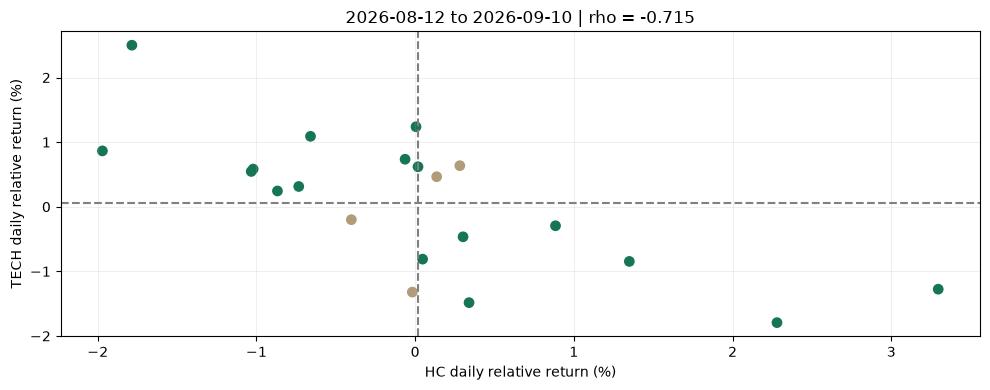

Means (%): {'HC': 0.018461, 'TECH': 0.063807}
rho = -18.574490 / 25.987853 = -0.714737


,HC,TECH,HC_deviation,TECH_deviation,Cov_product
Date,,,,,
2026-08-12,0.005476,1.238063,-0.012985,1.174256,-0.015248
2026-08-13,-0.733365,0.313588,-0.751826,0.249780,-0.187791
2026-08-14,-0.401868,-0.200419,-0.420329,-0.264227,0.111062
2026-08-17,0.281548,0.635893,0.263088,0.572085,0.150509
2026-08-18,2.279881,-1.793956,2.261421,-1.857763,-4.201184


In [6]:
sample = relative.tail(21) * 100
centered = sample - sample.mean()
products = centered.HC * centered.TECH
numerator = products.sum()
denominator = np.sqrt(centered.HC.pow(2).sum() * centered.TECH.pow(2).sum())
manual_rho = numerator / denominator
fig, ax = plt.subplots()
ax.scatter(sample.HC, sample.TECH, c=np.where(products < 0, '#167554', '#b29b79'), s=45)
ax.axvline(sample.HC.mean(), linestyle='--', color='gray')
ax.axhline(sample.TECH.mean(), linestyle='--', color='gray')
ax.set(xlabel='HC daily relative return (%)', ylabel='TECH daily relative return (%)',
       title=f'{sample.index[0].date()} to {sample.index[-1].date()} | rho = {manual_rho:.3f}')
plt.tight_layout()
plt.show()
print(f'Means (%): {sample.mean().round(6).to_dict()}')
print(f'rho = {numerator:.6f} / {denominator:.6f} = {manual_rho:.6f}')
display(sample.assign(HC_deviation=centered.HC, TECH_deviation=centered.TECH,
                      Cov_product=products).head(5).round(6))
assert np.isclose(manual_rho, sample.HC.corr(sample.TECH))

## 5. Is the result driven by a few dates?

Remove the three dates with the largest absolute covariance contributions, using the original window means.
Then recompute correlation and means on the remaining dates. This deliberately extreme sensitivity check is
**not a reason to discard valid observations**. The leave-one-out range checks every single-date deletion.
Neither range is a confidence interval. Formal inference needs dependence-aware resampling and a larger sample.

In [7]:
checks = []
for name in ['Absolute', 'Relative']:
    for window in [21, 63]:
        s = views[name].tail(window)
        d = s - s.mean()
        influential = (d.HC * d.TECH).abs().nlargest(3).index
        trimmed = s.drop(index=influential)
        loo = [s.drop(index=date).corr().iloc[0, 1] for date in s.index]
        checks.append([name, window, s.HC.corr(s.TECH), min(loo), max(loo),
                       trimmed.HC.corr(trimmed.TECH)])
display(pd.DataFrame(checks, columns=['View', 'Days', 'Original', 'LOO min', 'LOO max', 'Remove 3']).round(3))

,View,Days,Original,LOO min,LOO max,Remove 3
0,Absolute,21,-0.355,-0.393,-0.261,-0.027
1,Absolute,63,-0.441,-0.472,-0.408,-0.356
2,Relative,21,-0.715,-0.751,-0.657,-0.508
3,Relative,63,-0.727,-0.746,-0.699,-0.658


## 6. Does healthcare protect technology losses?

**Left:** technology tail days in the latest three years, defined by a daily return below its **previous-history
5th percentile** (at least 252 past observations). We observe that day's loss afterward; this is not a tradable same-day signal.
Check both healthcare's average return and its positive-return frequency.

**Right:** market states known before the day. High volatility means prior 21-day SPY volatility exceeds its
own previously observed expanding 75th percentile. Correlations use the individual daily observations in each state;
they are not averages of rolling correlations. Consecutive high-volatility days are clustered, so check the number of spells too.

**Interpretation:** losing less is useful diversification, but it is different from gaining when technology loses.
Negative relative correlation during stress can coexist with strongly positive absolute correlation.

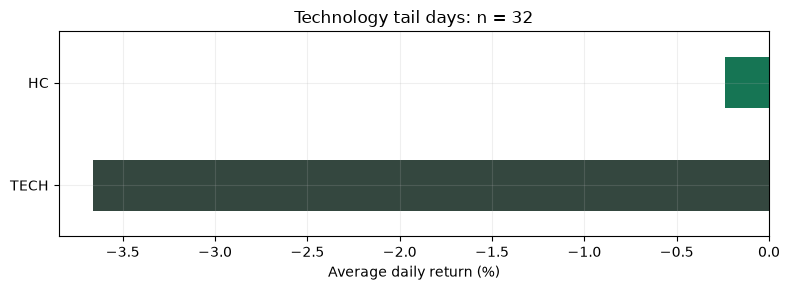

HC positive on 13 of 32 tail days: 40.6%
High-volatility days: 54 | contiguous spells in sample: 4


,State,Days,Absolute rho,Relative rho
0,Normal volatility,699,0.073,-0.679
1,High volatility,54,0.673,-0.695


In [8]:
tech_cutoff = df.TECH.expanding(252).quantile(0.05).shift(1)
vol = df.MKT.rolling(21).std().shift(1) * np.sqrt(252)
vol_cutoff = vol.expanding(252).quantile(0.75).shift(1)
high = (vol > vol_cutoff).loc[recent.index]
normal = (vol <= vol_cutoff).loc[recent.index]
tail = recent.loc[recent.TECH < tech_cutoff.loc[recent.index]]
state_rows = []
for label, mask in [('Normal volatility', normal), ('High volatility', high)]:
    s = recent.loc[mask]
    a = s[['HC', 'TECH']].sub(s.MKT, axis=0)
    state_rows.append([label, len(s), s.HC.corr(s.TECH), a.HC.corr(a.TECH)])
state_table = pd.DataFrame(state_rows, columns=['State', 'Days', 'Absolute rho', 'Relative rho'])
fig, ax = plt.subplots(figsize=(8, 3))
(tail[['TECH', 'HC']].mean() * 100).plot.barh(ax=ax, color=['#34473f', '#167554'])
ax.set(xlabel='Average daily return (%)', title=f'Technology tail days: n = {len(tail)}')
plt.tight_layout()
plt.show()
print(f'HC positive on {(tail.HC > 0).sum()} of {len(tail)} tail days: {(tail.HC > 0).mean():.1%}')
print(f'High-volatility days: {high.sum()} | contiguous spells in sample: {(high & ~high.shift(1, fill_value=False)).sum()}')
display(state_table.round(3))

## 7. Beta explains why absolute and relative correlation differ

Within the **same sample**, fit $r_i=\alpha_i+\beta_i r_M+e_i$ by OLS with an intercept.
The residuals are orthogonal to the market in that sample, giving these exact covariance identities:

$$\operatorname{Cov}(r_H,r_T)=\beta_H\beta_T\operatorname{Var}(r_M)+\operatorname{Cov}(e_H,e_T),$$
$$\operatorname{Cov}(r_H-r_M,r_T-r_M)=(\beta_H-1)(\beta_T-1)\operatorname{Var}(r_M)+\operatorname{Cov}(e_H,e_T).$$

If $0<\beta_H<1<\beta_T$, the market term is **positive for absolute returns** but **negative for relative returns**.
That alone can create benchmark-relative opposition. Subtracting a shared benchmark does not always cause negative correlation;
the beta configuration and residual covariance determine the result.

The table reports **covariance**, in daily percentage-points squared, not correlation.
Correlation also divides by both volatilities. These same-sample betas explain realized behavior;
they are **different from the lagged betas** in Section 2 and cannot be used as advance trading signals.

,HC beta,TECH beta,Market variance,Absolute market term,Relative market term,Residual covariance
Last 21 days,0.666,1.554,0.280,0.290,-0.052,-0.877
Last 63 days,-0.183,2.010,0.625,-0.230,-0.747,-0.828
Last 126 days,0.207,1.809,0.769,0.287,-0.494,-0.784
Normal volatility,0.389,1.551,0.675,0.407,-0.227,-0.316
High volatility,0.582,1.262,4.263,3.129,-0.467,-0.280


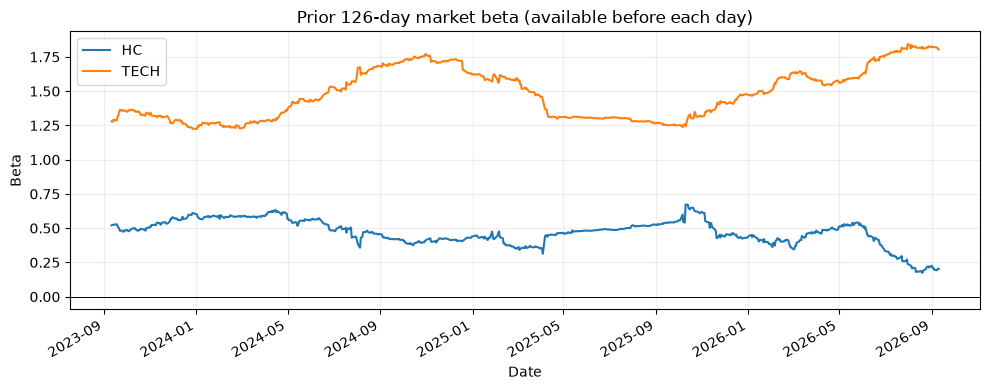

In [9]:
def decompose(s):
    v = s.MKT.var()
    if len(s) < 3 or not v > 0:
        return [np.nan] * 6
    b = s[['HC', 'TECH']].apply(lambda x: x.cov(s.MKT) / v)
    fitted = pd.DataFrame({col: b[col] * (s.MKT - s.MKT.mean()) for col in b.index})
    e = s[['HC', 'TECH']] - s[['HC', 'TECH']].mean() - fitted
    residual_cov = e.HC.cov(e.TECH)
    absolute_market = b.HC * b.TECH * v
    relative_market = (b.HC - 1) * (b.TECH - 1) * v
    a = s[['HC', 'TECH']].sub(s.MKT, axis=0)
    assert np.isclose(absolute_market + residual_cov, s.HC.cov(s.TECH), atol=1e-12)
    assert np.isclose(relative_market + residual_cov, a.HC.cov(a.TECH), atol=1e-12)
    return [b.HC, b.TECH, v * 10000, absolute_market * 10000,
            relative_market * 10000, residual_cov * 10000]

samples = {f'Last {w} days': df.tail(w) for w in [21, 63, 126]}
samples.update({'Normal volatility': recent.loc[normal], 'High volatility': recent.loc[high]})
decomposition = pd.DataFrame({name: decompose(s) for name, s in samples.items()},
    index=['HC beta', 'TECH beta', 'Market variance', 'Absolute market term', 'Relative market term', 'Residual covariance']).T
display(decomposition.round(3))
beta.loc[start:].plot(title='Prior 126-day market beta (available before each day)', ylabel='Beta')
plt.axhline(0, color='black', linewidth=0.7)
plt.tight_layout()
plt.show()

**Read the stress comparison:** when both betas are positive, a rise in market variance can overwhelm negative
residual covariance, making the absolute relationship positive. Negative relative correlation may survive at the same time.
Check the two market terms and the residual term before attributing the pattern to sector rotation.
Beta estimates that change sign across 21/63/126 days also warn against treating healthcare as a stable market hedge.

**Two different hedge ratios for $r_P=r_T+h r_H$:**

- Minimum-variance overlay: $h^*=-\operatorname{Cov}(r_T,r_H)/\operatorname{Var}(r_H)$.
  Negative absolute covariance implies a positive healthcare overlay, but adding it requires funding.
- Market-beta-neutral overlay: $h_\beta=-\beta_T/\beta_H$.
  Both positive betas require a healthcare short, and a near-zero healthcare beta makes the ratio unstable.

These are unconstrained one-factor calculations, not recommended positions. Neither is a fully funded allocation rule.
A dollar-neutral long-HC/short-TECH position generally remains exposed to the market, styles, and sector-specific risks.

## 8. What could this change in a portfolio?

For fixed weights, $\sigma_P^2=w_T^2\sigma_T^2+w_H^2\sigma_H^2+2w_Tw_H\operatorname{Cov}(r_T,r_H)$.
Negative covariance helps when **both weights have the same sign**. Opposite signs reverse that contribution:
long healthcare / short technology is a relative-performance bet, not automatically a lower-risk trade.

Compare a fixed **80% technology / 20% healthcare** allocation with **80% technology / 20% zero-return cash**.
Cash isolates the effect of reducing technology exposure. Below are sample annualized volatility estimates;
they are **not a backtest or forecasts**, exclude costs, and assume fixed daily exposures. Cash yield is omitted.
Different estimation windows show whether the apparent diversification benefit is stable.
If healthcare reduces volatility versus cash only in short windows, the benefit is conditional on the recent
relationship. It is not evidence that healthcare is always the better defensive asset.

In [10]:
risk = []
for label, s in [('Last 63 days', df.tail(63)), ('Last 126 days', df.tail(126)), ('Last 3 years', recent)]:
    risk.append([label, s.TECH.std(), (0.8 * s.TECH + 0.2 * s.HC).std(), (0.8 * s.TECH).std()])
risk_table = pd.DataFrame(risk, columns=['Sample', '100% TECH', '80% TECH + 20% HC', '80% TECH + 20% cash']).set_index('Sample')
display((risk_table * np.sqrt(252) * 100).round(2).rename_axis('Annualized volatility (%)'))
assert np.allclose(relative.HC, df.HC - df.MKT)
assert np.allclose(relative.TECH, df.TECH - df.MKT)
print('Checks passed: input contract, relative returns, Pearson calculation, and both covariance identities.')

,100% TECH,80% TECH + 20% HC,80% TECH + 20% cash
Annualized volatility (%),,,
Last 63 days,31.36,23.64,25.09
Last 126 days,30.38,23.74,24.30
Last 3 years,25.10,20.85,20.08


Checks passed: input contract, relative returns, Pearson calculation, and both covariance identities.


## 9. Investment meaning: evidence first, trade second

**What turning negative means:** recent deviations from each sector's own mean tend to offset each other.
A zero crossing is a noisy threshold, not a structural-break test. Relative negativity can reflect different market betas;
negative absolute correlation is a more direct diversification clue. Neither identifies tomorrow's winner.

| Observation | Investment implication | Evidence needed before increasing conviction |
|---|---|---|
| Absolute and residual correlations stay negative across windows | Candidate for a funded reduction of technology concentration | Stress results, stable covariance, turnover and costs in a walk-forward test |
| Only relative correlation is negative | May diversify benchmark-relative risk for same-sign active weights | Benchmark fit and beta-adjusted residuals; do not call this crash protection |
| Absolute correlation rises in high market volatility | Healthcare may lose alongside technology when protection matters most | More independent stress episodes and explicit portfolio loss limits |
| The last 21 days differ from 63/126 days or depend on a few events | Treat the estimate as uncertain and avoid large correlation-based changes | Event attribution, stability after new observations, dependence-aware intervals |
| Valuation and earnings support healthcare relative to technology | Potential directional thesis, separate from the correlation thesis | Point-in-time valuation, EPS revisions, catalysts, and a defined exit condition |

**Could correlation become more negative?** Yes, mathematically, if the covariance falls relative to both volatilities.
Economically, opposing sector earnings shocks, repricing, or exposures could contribute. But a stronger shared market shock
could reverse absolute correlation. The current coefficient alone estimates neither direction nor probability.

**Practical sequence:** set the objective (lower concentration, protect a dollar loss, or take an active sector view),
compare a modest funded reallocation with cash, then evaluate walk-forward costs and stress losses.
For explicit crash protection, compare market hedges or protective options separately, including premium and basis risk.
The notebook does not establish a directional buy/sell signal or a suitable position size for a particular account.

## 10. Additional angles and data to request

| Next test | Data required | What it could resolve |
|---|---|---|
| Valuation vs. earnings | Monthly point-in-time forward P/E, NTM EPS, EPS revisions and dispersion for both sectors; 5-10+ years | Cheap for a reason, or an improving relative-value opportunity? Separate earnings growth from multiple changes. |
| Concentration and subsectors | Historical constituent weights, classifications and total returns | Is this a few mega-cap technology stocks or one healthcare subsector? Recompute equal-weight and ex-top-holdings results. |
| Macro and style exposure | Rates and real-yield changes, credit spreads, volatility, value/growth, momentum and quality factors | Does the negative residual survive more than a one-market-factor model? Use lagged states and out-of-sample estimates. |
| Event attribution | Dated earnings, drug/regulatory, reimbursement and product announcements; fund flows as supporting evidence | Are large scatter points repeatable mechanisms or isolated shocks? Prices alone do not establish flows or causality. |
| Forward usefulness of a zero crossing | Existing daily returns; initial study in Sections 11-13 below | Extend the event study with regime controls and an untouched future sample; add implementation costs before trading. |
| Benchmark and history robustness | Exact sector total-return indices plus broader fund proxies | Does the result survive index construction, reclassification and benchmark choice? Long history can sacrifice relevance. |

**Priority request:** point-in-time valuation/EPS and historical constituent weights. Current valuation snapshots cannot
explain past correlation changes. Preserve observation date, publication/as-of date, currency, forecast horizon and aggregation
method; avoid mixing a live constituents list with historical returns. These additional data have **not** been pulled here.

References: [yfinance history parameters](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.history.html),
[xbbg legacy BDH and adjustment examples](https://app.readthedocs.org/projects/xbbg/downloads/pdf/latest/),
[CFA Institute: active return and portfolio risk](https://www.cfainstitute.org/insights/professional-learning/refresher-readings/2026/analysis-active-portfolio-management).
All empirical outputs above are calculated from the input `df`; references support methodology, not the observed numbers.

## 11. Correlation alongside the SPX index

**Reading the new chart:** columns show the full common history and the latest three years.
Within each column the panels share dates. Correlation stays on its natural **-1 to +1** scale;
SPX is **rebased to 100 at each panel's first date**, on a labelled log scale so equal percentage changes
have equal vertical distances. There is no arbitrary dual-axis overlay.
Green shading marks persistent **absolute** negative correlation; triangles mark retained event onsets.
Relative returns still subtract SPY; SPX is the separately observed market price index.
This timeline is descriptive. A visually close match is not a forecast test.

**Define "a lot of negative correlation" before examining returns:** a 21-day daily-return correlation is
below a threshold today and on **at least 15 of the last 21 dates**, with all 21 correlation observations available.
Compare **absolute < 0**, **relative < 0**, and **relative < -0.5** (depth sensitivity).
These are illustrative rules, not optimized thresholds or statistically independent observations.

,Latest rho,Below threshold / 21,Qualifies now,Last onset,Current age (days),All onsets,Retained
Rule,,,,,,,
Absolute < 0,-0.355,21,True,2026-05-29,72,7,7
Relative < 0,-0.715,21,True,2026-01-27,157,116,57
Relative < -0.5,-0.715,21,True,2026-02-27,135,46,25


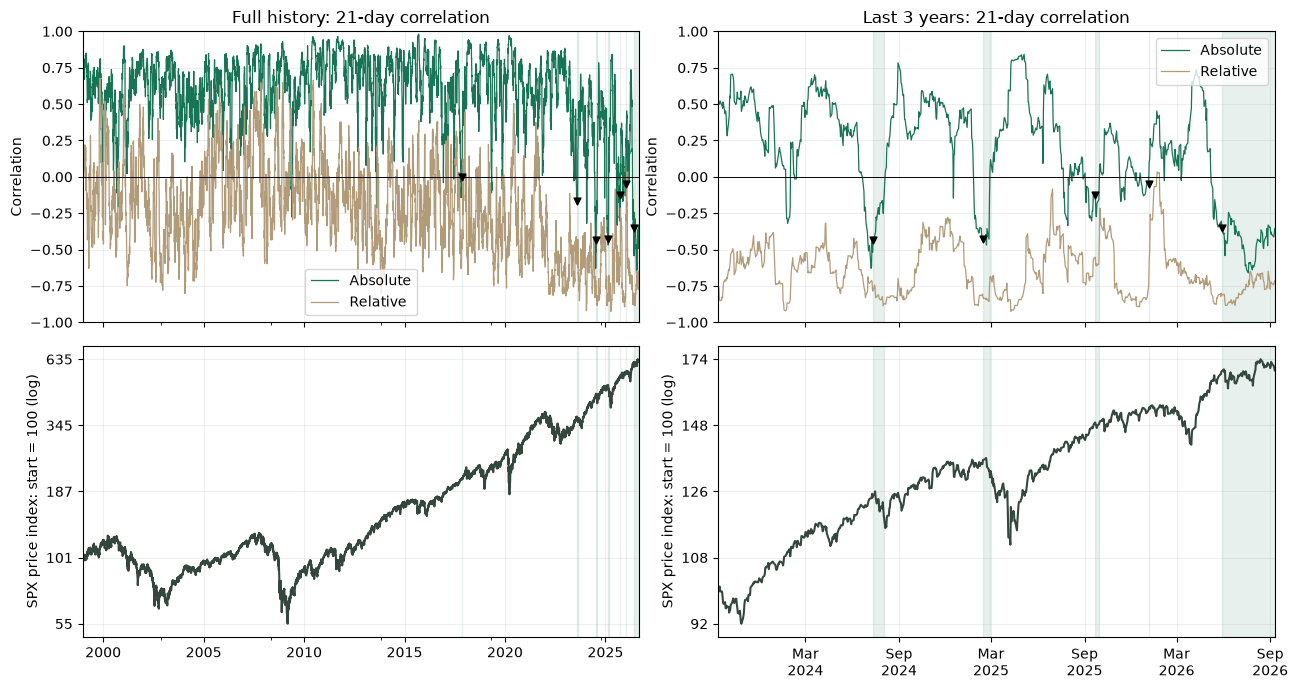

In [11]:
import matplotlib.dates as mdates
assert isinstance(spx, pd.Series) and spx.index.equals(df.index)
assert np.isfinite(spx.to_numpy()).all() and (spx > 0).all()
HORIZONS, GAP = [5, 21, 63], 63
corr21 = pd.DataFrame({name: x.HC.rolling(21).corr(x.TECH) for name, x in views.items() if name != 'Market residual'})
rules = {'Absolute < 0': ('Absolute', 0), 'Relative < 0': ('Relative', 0), 'Relative < -0.5': ('Relative', -0.5)}
eligible = corr21.notna().all(axis=1).rolling(21).sum().eq(21)
flags, onsets, selected, state_rows, event_rows = {}, {}, {}, [], []

def spaced(positions, gap=GAP):
    kept = []
    for p in positions:
        if not kept or p - kept[-1] >= gap:
            kept.append(int(p))
    return kept

for rule, (view, threshold) in rules.items():
    below = corr21[view] < threshold
    count = below.rolling(21).sum()
    flag = below & count.ge(15) & eligible
    positions = np.flatnonzero(flag & ~flag.shift(1, fill_value=False))
    keep = spaced(positions)
    flags[rule], onsets[rule], selected[rule] = flag, positions, keep
    age = len(df) - int(positions[-1]) if flag.iloc[-1] else 0
    state_rows.append([rule, corr21[view].iloc[-1], int(count.iloc[-1]), bool(flag.iloc[-1]),
                       df.index[positions[-1]] if len(positions) else pd.NaT, age, len(positions), len(keep)])
    for p in positions:
        event_rows.append([rule, df.index[p], p, p in keep, corr21[view].iloc[p],
                           df.index[p + 1] if p + 1 < len(df) else pd.NaT])
current_state = pd.DataFrame(state_rows, columns=['Rule', 'Latest rho', 'Below threshold / 21', 'Qualifies now',
    'Last onset', 'Current age (days)', 'All onsets', 'Retained']).set_index('Rule')
event_log = pd.DataFrame(event_rows, columns=['Rule', 'Signal date', 'Position', 'Retained', 'rho', 'Entry close'])
display(current_state.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex='col')
for col, (label, dates) in enumerate([('Full history', df.index), ('Last 3 years', recent.index)]):
    corr21.loc[dates].plot(ax=axes[0, col], color=['#167554', '#b29b79'], linewidth=0.9)
    axes[0, col].axhline(0, color='black', linewidth=0.7)
    axes[0, col].set(title=label + ': 21-day correlation', ylim=(-1, 1), ylabel='Correlation')
    markers = df.index[selected['Absolute < 0']].intersection(dates)
    axes[0, col].scatter(markers, corr21.loc[markers, 'Absolute'], marker='v', color='black', s=24, zorder=4)
    indexed = spx.loc[dates] / spx.loc[dates[0]] * 100
    axes[1, col].plot(dates, indexed, color='#34473f')
    axes[1, col].set(yscale='log', ylabel='SPX price index: start = 100 (log)')
    ticks = np.geomspace(indexed.min(), indexed.max(), 5)
    axes[1, col].set_yticks(ticks, labels=[f'{x:.0f}' for x in ticks])
    axes[1, col].minorticks_off()
    locator = mdates.YearLocator(5) if col == 0 else mdates.MonthLocator(interval=6)
    axes[1, col].xaxis.set_major_locator(locator)
    axes[1, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y' if col == 0 else '%b\n%Y'))
    axes[1, col].set_xlim(dates[0], dates[-1])
    for ax in axes[:, col]:
        ax.fill_between(dates, 0, 1, where=flags['Absolute < 0'].loc[dates],
                        transform=ax.get_xaxis_transform(), color='#167554', alpha=0.10)
plt.tight_layout()
plt.show()

## 12. What happened after each persistent-negative episode?

**Timing:** signal at close $t$; assume entry at the **next trading day's close**, $t+1$.
The $h$-day outcome is $L_{t+1+h}/L_{t+1}-1$, for **5, 21, and 63 trading days**.
This excludes both the signal day's return and the return up to the entry close. There are no same-close fills.
SPX uses its price level; sector wealth levels compound adjusted returns. SPX excludes dividends;
TECH and HC include distribution adjustments. **HC - TECH** is a difference in cumulative returns, in percentage points.

**One event, not a daily stream of repeated signals:** take the first qualifying day of each continuous episode,
then retain onsets at least 63 trading days apart within each rule. All holding windows up to 63 days therefore
do not overlap within a rule. Apply spacing before examining future data; unfinished outcomes remain missing.
An ongoing episode produces no new onset just because another 63 days pass. Rules can share events with each other.

**Comparison:** the table gives event mean, median, positive fraction, and 10th percentile, plus the mean across
all eligible historical start dates. The same-year adjustment subtracts each event year's unconditional mean,
then averages the differences. These baselines overlap and are descriptive controls, not independent trials or alpha estimates.
Year controls use realized historical returns and are not available as trading signals.

In [12]:
levels = (1 + df[['TECH', 'HC']]).cumprod()
levels.insert(0, 'SPX', spx)
forward, baseline, summaries = {}, {}, []
for h in HORIZONS:
    f = levels.shift(-(h + 1)).div(levels.shift(-1)) - 1
    f['HC - TECH'] = f.HC - f.TECH
    forward[h] = f
    base = f.loc[eligible].dropna()
    baseline[h] = base
    by_year = base.groupby(base.index.year).mean()
    for rule, positions in selected.items():
        outcomes = f.loc[df.index[positions]].dropna()
        year_base = by_year.reindex(outcomes.index.year).set_axis(outcomes.index)
        for asset in f.columns:
            x = outcomes[asset]
            summaries.append([rule, h, asset, len(x), len(positions) - len(x), x.mean() * 100,
                x.median() * 100, x.gt(0).mean() * 100, x.quantile(0.1) * 100,
                base[asset].mean() * 100, (x - year_base[asset]).mean() * 100])
summary = pd.DataFrame(summaries, columns=['Rule', 'Days', 'Asset', 'N', 'Pending', 'Mean %', 'Median %',
    'Positive %', 'P10 %', 'Base mean %', 'Year-adjusted mean pp']).set_index(['Rule', 'Days', 'Asset'])
print('MAIN RULE: sustained absolute negative correlation; returns in %, spread in pp')
display(summary.loc['Absolute < 0'].round(2))
print('DEFINITION SENSITIVITY: 21-day outcomes; do not select a rule by the highest realized return')
display(summary.xs(21, level='Days')[['N', 'Mean %', 'Median %', 'Positive %', 'Year-adjusted mean pp']].round(2))
for h in HORIZONS:
    for asset in ['SPX', 'TECH', 'HC']:
        event_log[f'{asset} {h}d %'] = forward[h][asset].reindex(event_log['Signal date']).to_numpy() * 100
summary.to_csv('negative_corr_forward_summary.csv')
event_log.to_csv('negative_corr_event_ledger.csv', index=False)
print('EVERY ABSOLUTE EVENT: Retained=False means excluded by the 63-day spacing rule; NaN means unfinished')
display(event_log.loc[event_log.Rule.eq('Absolute < 0'), ['Signal date', 'Entry close', 'Retained', 'rho',
    'SPX 21d %', 'TECH 21d %', 'HC 21d %', 'SPX 63d %', 'TECH 63d %', 'HC 63d %']].round(4))

MAIN RULE: sustained absolute negative correlation; returns in %, spread in pp


N  Pending  Mean %  Median %  Positive %  P10 %  Base mean %  \
Days Asset                                                                     
5    SPX        7        0   -1.16     -1.19       28.57  -2.67         0.16   
     TECH       7        0   -2.35     -2.04       28.57  -5.75         0.25   
     HC         7        0    0.89      0.66       57.14  -0.91         0.19   
     HC - TECH  7        0    3.24      1.04       71.43  -0.68        -0.06   
21   SPX        7        0   -1.50     -1.54       42.86  -5.06         0.66   
     TECH       7        0   -3.77     -5.07       42.86  -9.76         1.04   
     HC         7        0    2.70      2.35       71.43  -1.65         0.78   
     HC - TECH  7        0    6.46      5.46       85.71  -0.51        -0.26   
63   SPX        7        0    0.74      1.13       57.14  -2.48         1.92   
     TECH       7        0    0.11     -1.28       42.86  -3.80         3.07   
     HC         7        0    3.11      3.60       57.14  -5.63         2.22   
     HC - TECH  7        0    2.99     -0.79       42.86  -5.94        -0.84   

                Year-adjusted mean pp  
Days Asset                             
5    SPX                        -1.53  
     TECH                       -3.02  
     HC                          0.65  
     HC - TECH                   3.67  
21   SPX                        -3.07  
     TECH                       -6.63  
     HC                          1.58  
     HC - TECH                   8.21  
63   SPX                        -4.28  
     TECH                       -9.82  
     HC                          0.04  
     HC - TECH                   9.87

DEFINITION SENSITIVITY: 21-day outcomes; do not select a rule by the highest realized return


N  Mean %  Median %  Positive %  \
Rule            Asset                                         
Absolute < 0    SPX         7   -1.50     -1.54       42.86   
                TECH        7   -3.77     -5.07       42.86   
                HC          7    2.70      2.35       71.43   
                HC - TECH   7    6.46      5.46       85.71   
Relative < 0    SPX        57    1.48      2.21       64.91   
                TECH       57    2.10      3.00       64.91   
                HC         57    1.91      1.79       71.93   
                HC - TECH  57   -0.19     -1.04       38.60   
Relative < -0.5 SPX        25   -0.31      1.71       56.00   
                TECH       25   -0.75      1.00       56.00   
                HC         25   -0.65     -1.20       44.00   
                HC - TECH  25    0.11      0.84       52.00   

                           Year-adjusted mean pp  
Rule            Asset                             
Absolute < 0    SPX                        -3.07  
                TECH                       -6.63  
                HC                          1.58  
                HC - TECH                   8.21  
Relative < 0    SPX                         0.82  
                TECH                        0.97  
                HC                          1.03  
                HC - TECH                   0.05  
Relative < -0.5 SPX                        -1.18  
                TECH                       -2.06  
                HC                         -1.48  
                HC - TECH                   0.58

EVERY ABSOLUTE EVENT: Retained=False means excluded by the 63-day spacing rule; NaN means unfinished


,Signal date,Entry close,Retained,rho,SPX 21d %,TECH 21d %,HC 21d %,SPX 63d %,TECH 63d %,HC 63d %
0,2017-11-10,2017-11-13,True,-0.0004,3.0180,1.0554,3.3219,4.4022,4.3890,3.5990
1,2023-08-09,2023-08-10,True,-0.1654,0.4169,3.3008,-1.3795,-1.9256,4.7612,-4.5497
2,2024-07-12,2024-07-15,True,-0.4367,-3.4946,-8.7695,2.3486,3.2641,-1.2789,4.5441
3,2025-02-14,2025-02-18,True,-0.4281,-7.4114,-11.2529,1.6607,-2.7079,-2.9725,-6.6635
4,2025-09-22,2025-09-23,True,-0.1274,0.6381,1.8807,6.5868,3.3284,3.7615,13.8903
5,2026-01-05,2026-01-06,True,-0.0487,-2.1083,-7.5145,-2.0558,-2.3328,-3.2621,-4.9369
6,2026-05-29,2026-06-01,True,-0.3535,-1.5359,-5.0668,8.3899,1.1340,-4.6167,15.8632


**Read the paths:** thin lines are individual retained absolute-negative events; thick lines are their median;
the shaded band is the event 25th-75th percentile, **not a confidence interval**.
The dashed line is the median path across all eligible dates with a complete 63-day outcome.
Every path starts at zero at the next-close entry. Only fully observed 63-day events enter this figure,
so its sample can differ from shorter-horizon tables. Means and median paths need not agree.

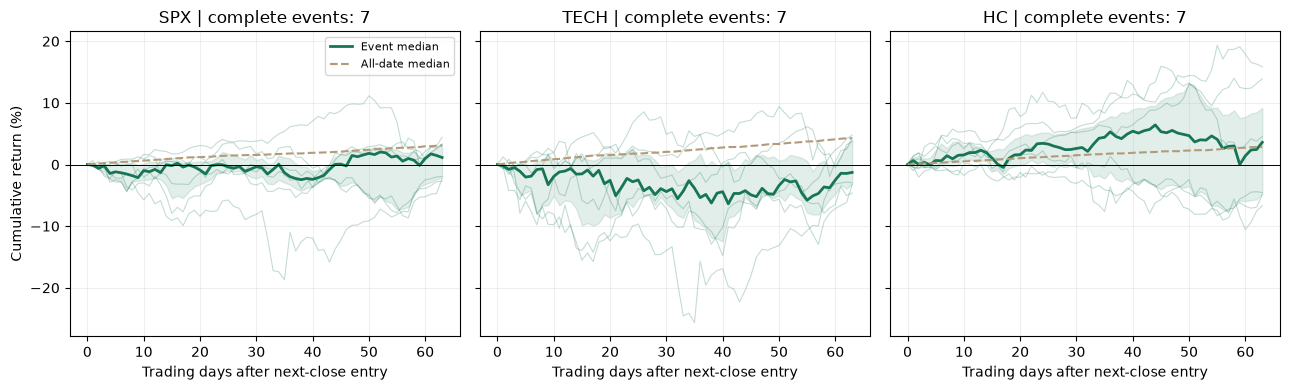

In [13]:
complete_dates = df.index[selected['Absolute < 0']].intersection(forward[63].dropna().index)
base_dates = baseline[63].index
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, asset in zip(axes, ['SPX', 'TECH', 'HC']):
    paths = pd.DataFrame({h: (levels[asset].shift(-(h + 1)) / levels[asset].shift(-1) - 1) * 100
                          for h in range(64)}).loc[complete_dates]
    base_path = pd.Series({h: ((levels[asset].shift(-(h + 1)) / levels[asset].shift(-1) - 1)
                              .loc[base_dates] * 100).median() for h in range(64)})
    ax.plot(paths.columns, paths.T, color='#167554', alpha=0.25, linewidth=0.8)
    ax.fill_between(paths.columns, paths.quantile(0.25), paths.quantile(0.75), color='#167554', alpha=0.12)
    ax.plot(paths.columns, paths.median(), color='#167554', linewidth=2, label='Event median')
    ax.plot(base_path.index, base_path, color='#b29b79', linestyle='--', label='All-date median')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set(title=f'{asset} | complete events: {len(paths)}', xlabel='Trading days after next-close entry')
axes[0].set_ylabel('Cumulative return (%)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 13. Is today's episode comparable to those historical onsets?

**Onset and current age are different questions.** If today's episode is already 72 trading days old,
an average measured from its first day is not a forecast from today. Match each rule's **current episode age**:
in every historical episode that lasted at least that long, observe the same-age date, apply the same spacing rule,
and measure the following 21-day return after next-close entry. A value of **N = 0 means no completed analogue**,
not a zero expected return. This age comparison is exploratory: today's age is selected from the current snapshot.
Age counts qualifying trading days including the onset, not negative-correlation days before qualification.

In [14]:
phase_rows = []
for rule, flag in flags.items():
    age = int(current_state.loc[rule, 'Current age (days)'])
    anchors = [int(p + age - 1) for p in onsets[rule] if age > 0 and p + age <= len(df)
               and flag.iloc[p:p + age].all()]
    positions = spaced(anchors)
    sample_phase = forward[21].loc[df.index[positions]].dropna()
    phase_rows.append([rule, age, len(sample_phase), len(positions) - len(sample_phase),
                       *[sample_phase[a].mean() * 100 for a in ['SPX', 'TECH', 'HC']]])
phase_summary = pd.DataFrame(phase_rows, columns=['Rule', 'Current age', 'Completed N', 'Pending',
    'SPX 21d mean %', 'TECH 21d mean %', 'HC 21d mean %']).set_index('Rule')
display(phase_summary.round(2))
phase_summary.to_csv('negative_corr_current_phase.csv')
main = summary.xs(('Absolute < 0', 21), level=['Rule', 'Days'])
print(f"Onset study: {int(main.loc['SPX', 'N'])} completed 21-day absolute-negative events.")
print(f"Current-age study: {int(phase_summary.loc['Absolute < 0', 'Completed N'])} completed absolute-negative analogues.")
spread63 = summary.xs(('Absolute < 0', 63, 'HC - TECH'))
print(f"63-day HC - TECH: mean {spread63['Mean %']:.2f} pp; median {spread63['Median %']:.2f} pp; positive in {spread63['Positive %']:.1f}% of events.")

,Current age,Completed N,Pending,SPX 21d mean %,TECH 21d mean %,HC 21d mean %
Rule,,,,,,
Absolute < 0,72,0,1,NaN,NaN,NaN
Relative < 0,157,2,1,-2.74,-2.86,-3.91
Relative < -0.5,135,0,1,NaN,NaN,NaN


Onset study: 7 completed 21-day absolute-negative events.
Current-age study: 0 completed absolute-negative analogues.
63-day HC - TECH: mean 2.99 pp; median -0.79 pp; positive in 42.9% of events.


**What this adds to the investment decision**

- **Direction vs. protection:** a positive HC-minus-TECH spread can come from healthcare rising, technology falling,
  or both losing with healthcare losing less. Read the three individual asset outcomes before proposing a trade.
- **Time horizon:** weak near-term SPX/technology returns followed by recovery would suggest a rotation or adjustment
  episode, not a permanent bear-market forecast. Check the actual 5/21/63-day table and individual paths.
  A positive 63-day mean spread with a negative median means large healthcare wins can dominate the average;
  the typical event need not favor healthcare.
- **Base rates and regimes:** positive event returns are not sufficient if normal returns are also positive.
  Inspect the baseline and same-year adjustment. A handful of events concentrated in recent years is weak evidence,
  even when outcomes agree; non-overlapping holding periods do not make macro regimes independent.
- **Depth is not duration:** relative correlation below zero is common; a deeper threshold or persistent absolute
  negativity selects a different set of dates. Opposite results across rules weaken any universal "negative = bearish" claim.
- **For today:** a long current episode with few same-age precedents leaves its next return poorly identified.
  Do not recycle the onset average as today's price target or a short signal. Keep correlation as a risk-allocation input;
  require earnings/valuation evidence and a genuinely untouched forward sample before treating it as a directional edge.

This is a **historical event study**, not a transaction-cost-adjusted strategy or a causal test. Rules were specified
for this exploratory exercise; the past is not an untouched out-of-sample experiment. Threshold, horizon, and age comparisons
are not separate confirmations. Follow-up work should match prior market trend/volatility and sector momentum,
test sensitivity without selecting the best result, and evaluate subsequent unseen events.

Method reference: [CFA Institute: backtesting, look-ahead bias and simulation](https://www.cfainstitute.org/insights/professional-learning/refresher-readings/2026/backtesting-and-simulation).
All event results use the labelled Yahoo snapshot and the timing conventions above; no valuation data were added.